In [ ]:
import os
from google.colab import drive

# 1. Mount your Google Drive into Colab
drive.mount('/content/drive')

# 2. Set your Kaggle API token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_3bb4b581677bdf0f17a4c50241b10ada'

# 3. Create a folder in your Google Drive for the dataset
# (This creates a folder named 'cnn_dataset' inside your Drive)
!mkdir -p "/content/drive/My Drive/cnn_dataset"

# 4. Download dataset directly into your Google Drive folder
!kaggle datasets download -d alxmamaev/flowers-recognition -p "/content/drive/My Drive/cnn_dataset"

# 5. Unzip the dataset inside Google Drive
!unzip -q "/content/drive/My Drive/cnn_dataset/flowers-recognition.zip" -d "/content/drive/My Drive/cnn_dataset/"

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:02<00:00, 86.3MB/s]



In [ ]:
import os
import tensorflow as tf

# 1. Define the dataset path inside your Google Drive
# (The flowers dataset unzips into a folder called 'flowers' or 'flowers-recognition')
base_dir = '/content/drive/My Drive/cnn_dataset'

# List contents to confirm folder structure
print("Files in Drive folder:", os.listdir(base_dir))

# 2. Load images into training and validation datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

print("Class names found:", train_ds.class_names)

Files in Drive folder: ['flowers-recognition.zip', 'flowers']
Found 4317 files belonging to 1 classes.
Using 3454 files for training.
Found 4317 files belonging to 1 classes.
Using 863 files for validation.
Class names found: ['flowers']


In [ ]:
# Update base_dir to point inside the 'flowers' folder
base_dir = '/content/drive/My Drive/cnn_dataset/flowers'

# Load the training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# Load the validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

print("Class names found:", train_ds.class_names)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Class names found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [ ]:
from tensorflow.keras import layers, models

# 1. Build the CNN Model Architecture
model = models.Sequential([
    # Rescale RGB pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # 1st Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2nd Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Regularization to prevent overfitting
    layers.Dense(5, activation='softmax')  # 5 classes output
])

# 2. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the Model for 10 Epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)





Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.3752 - loss: 1.4139 - val_accuracy: 0.4565 - val_loss: 1.1797
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5148 - loss: 1.1731 - val_accuracy: 0.5805 - val_loss: 1.0054
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.5793 - loss: 1.0757 - val_accuracy: 0.5875 - val_loss: 0.9998
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6422 - loss: 0.9387 - val_accuracy: 0.6257 - val_loss: 0.9449
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.6818 - loss: 0.8512 - val_accuracy: 0.6674 - val_loss: 0.8462
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7142 - loss: 0.7829 - val_accuracy: 0.6686 - val_loss: 0.8511
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.7490 - loss: 0.6896 - val_accuracy: 0.7010 - val_loss: 0.8066
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7849 - loss: 0.5756 - val_accuracy: 0.690

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grab one batch from validation data
for images, labels in val_ds.take(1):
    # Predict on the first image in the batch
    img = images[0]
    true_label = class_names[labels[0]]

    # Format image for prediction
    img_array = tf.expand_dims(img, 0)
    predictions = model.predict(img_array)
    pred_label = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    # Display image and prediction
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"True: {true_label} | Pred: {pred_label} ({confidence:.1f}%)")
    plt.axis("off")
    plt.show()

NameError: name 'class_names' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


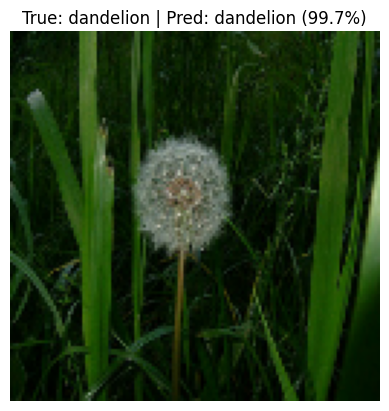

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Get class names directly from the dataset
class_names = train_ds.class_names

# 2. Grab one batch from validation data
for images, labels in val_ds.take(1):
    # Select the first image in the batch
    img = images[0]
    true_label = class_names[labels[0]]

    # Format image for prediction
    img_array = tf.expand_dims(img, 0)
    predictions = model.predict(img_array)
    pred_label = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    # Display image and prediction result
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"True: {true_label} | Pred: {pred_label} ({confidence:.1f}%)")
    plt.axis("off")
    plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# 1. Subtle Data Augmentation (keeps model realistic and custom)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
])

# 2. Updated Model Structure
num_classes = len(train_ds.class_names)

model = models.Sequential([
    # Input & Preprocessing
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    data_augmentation,

    # Feature Extraction Blocks with light L2 regularization
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),  # Moderate dropout
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train for 12 to 15 Epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)



Epoch 1/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.3932 - loss: 1.4569 - val_accuracy: 0.4971 - val_loss: 1.1823
Epoch 2/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.5220 - loss: 1.2030 - val_accuracy: 0.5550 - val_loss: 1.0837
Epoch 3/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5825 - loss: 1.1171 - val_accuracy: 0.5991 - val_loss: 1.0378
Epoch 4/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6048 - loss: 1.0342 - val_accuracy: 0.6257 - val_loss: 0.9664
Epoch 5/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6511 - loss: 0.9480 - val_accuracy: 0.6628 - val_loss: 0.8841
Epoch 6/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.6812 - loss: 0.8879 - val_accuracy: 0.6883 - val_loss: 0.8451
Epoch 7/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6928 - loss: 0.8516 - val_accuracy: 0.6871 - val_loss: 0.8628
Epoch 8/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7105 - loss: 0.8281 - val_accu

In [ ]:
# Save the model in the recommended native Keras format
model.save('flower_cnn_model.keras')
print("Model saved successfully!")

Model saved successfully!
